# 0. import

In [ ]:
# --- plot_revision setup ---
import sys
from pathlib import Path
_HERE = Path.cwd().resolve()
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR, RESULT_HUMAN_DIR, RESULT_MOUSE_DIR, RESULT_MULTI_DIR,
    SPC_MULTI_CSV, CLAUDE_CLADE_DIR, TREE_NWK,
    RESULT_RETRIEVAL_DIR, GAP_HUMAN_CSV, GAP_MOUSE_CSV,
    CKPT_ROOT, EPI_EVO2HIC_DIR, PRETRAIN_CKPT_DIR, PRETRAIN_CKPT,
    SR_EVO2HIC_HUMAN_DIR, SEQ2HIC_CKPT,
    HIC_DATA_ROOT, HIC_RAW_DIR, HIC_RAW, DNA_FASTA, MOTIF_MEME,
    EVO2_EMB_HUMAN, EVO2_EMB_MOUSE, TRACKS_GM12878_CHR10_NPY,
    ORCA_MALLPREDS_PTH, ORCA_EXPECTED_NPY,
    MOTIF_STATS_CSV,
    HUMAN_MERGED_CSV, HUMAN_INTER_DIR,
    HIC2TRACK_DIR, HIC2TRACK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [62]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.lines import Line2D

from importlib import reload
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.patches as patches

from plot_settings import *

from scipy.stats import gaussian_kde, spearmanr
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-white')


In [63]:
chromosomes = {
    'human': [9,10],
    'mouse': [1,2,3,4]
}

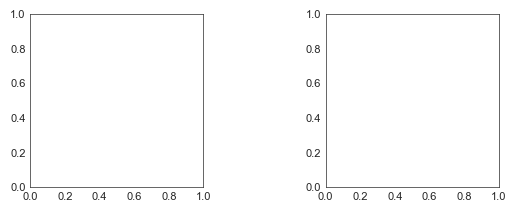

In [64]:
fig = plt.figure(figsize=(8.27, 3))

gs = gridspec.GridSpec(
    3, 5,  
    figure=fig,
    height_ratios=[0.5, 3, 0.5],
    width_ratios = [0.5, 2, 0.5, 2, 0.5],
    hspace=0.0,
    # wspace=0.35
)

axes = []
for i, row in enumerate([1]):
    row_axes = []
    for j in [1,3]:
        ax = fig.add_subplot(gs[row, j])
        row_axes.append(ax)
    axes.append(row_axes)

axes = np.array(axes)
for ax in axes.flatten():
    ax.set_aspect('equal')
    # ax.axis('off')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)


In [65]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


# 1 Embedding similarity (deprecated)

In [66]:
# def read(f, norm=True):
#     emb = np.load(f)
#     emb = emb.transpose(-1, -2)
#     if norm:
#         emb /= np.linalg.norm(emb, axis=-1, keepdims=True)
#     emb = np.nan_to_num(emb)
#     return emb
# def compute_density(x, y):
#     xy = np.vstack([x, y])
#     return gaussian_kde(xy)(xy)


In [67]:
# emb_train_evo2 = np.concatenate([
#     np.memmap(str(EVO2_EMB_HUMAN / 'chr9.embedding'), mode='r', dtype=np.float16, shape=(69198, 4096)).copy().astype(np.float32),
#     np.memmap(str(EVO2_EMB_HUMAN / 'chr9.rev.embedding'), mode='r', dtype=np.float16, shape=(69198, 4096)).copy().astype(np.float32)
# ], axis=-1)
# emb_train_evo2 /= np.linalg.norm(emb_train_evo2, axis=-1, keepdims=True)

# emb_train_evohic    = read(str(PRETRAIN_CKPT_DIR / 'human_embeds/dna_emb_9.npy'))
# emb_train_alignment = read(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/human_embeds/dna_emb_9.npy'))

# def pad1(x):
#     return np.pad(x, ((0,0), (1,0)), constant_values=1)

# def find_proj_emb(emb_s, emb_t):
#     A = np.linalg.lstsq(pad1(emb_s), emb_t)[0]
#     return A

# proj0 = find_proj_emb(emb_train_evohic, emb_train_evo2)
# proj1 = find_proj_emb(emb_train_alignment, emb_train_evo2)

## Human

In [68]:
# emb_evo2_human = np.concatenate([
#     np.memmap(str(EVO2_EMB_HUMAN / 'chr10.embedding'), mode='r', dtype=np.float16, shape=(66899, 4096)).copy().astype(np.float32),
#     np.memmap(str(EVO2_EMB_HUMAN / 'chr10.rev.embedding'), mode='r', dtype=np.float16, shape=(66899, 4096)).copy().astype(np.float32)
# ], axis=-1)
# emb_evo2_human /= np.linalg.norm(emb_evo2_human, axis=-1, keepdims=True)

# emb_evohic_human    = read(str(PRETRAIN_CKPT_DIR / 'human_embeds/dna_emb_10.npy'))
# emb_evohic_human_proj = pad1(emb_evohic_human) @ proj0

# emb_alignment_human = read(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/human_embeds/dna_emb_10.npy'))
# emb_alignment_human_proj = pad1(emb_alignment_human) @ proj1


In [69]:
# import torch
# def get_ranks(emb_evo2, emb_evohic_proj, emb_alignment_proj):
#     np.random.seed(42)
#     N = 5000
#     ind0 = np.random.choice(emb_evo2.shape[0]-1000, N)+500
#     emb_evohic_proj = emb_evohic_proj[ind0]
#     emb_alignment_proj = emb_alignment_proj[ind0]
#     emb_evohic_proj = torch.from_numpy(emb_evohic_proj).float().to('cuda')
#     emb_alignment_proj = torch.from_numpy(emb_alignment_proj).float().to('cuda')
#     emb_evo2 = torch.from_numpy(emb_evo2).float().to('cuda')
#     emb_evohic_proj /= torch.norm(emb_evohic_proj, dim=-1, keepdim=True)
#     emb_alignment_proj /= torch.norm(emb_alignment_proj, dim=-1, keepdim=True)

#     sim0 = emb_evohic_proj @ emb_evo2.transpose(-1, -2)
#     sim1 = emb_alignment_proj @ emb_evo2.transpose(-1, -2)

#     rank0 = (sim0 >= torch.diag(sim0)[:, None]).sum(dim=-1)
#     rank1 = (sim1 >= torch.diag(sim1)[:, None]).sum(dim=-1)

#     return rank0.cpu().numpy(), rank1.cpu().numpy()

In [70]:
# Xh, Yh = get_ranks(emb_evo2_human, emb_evohic_human_proj, emb_alignment_human_proj)

In [71]:
# def plot_two_violin(ax, x, y, labels=("X", "Y"), palette="Set2", ylabel="Cosine sim.", title=None, rotation=20):
#     """
#     在给定的 ax 上画两个序列的小提琴图。
    
#     参数：
#         ax: matplotlib.axes.Axes 对象
#         x, y: 两个数值序列（list 或 numpy array）
#         labels: 两个组的标签 (默认: ("X", "Y"))
#         palette: 调色板
#         ylabel: y 轴标题
#         title: 图标题
#     """
#     ax.clear()
#     ax.set_aspect('auto')
#     df = pd.DataFrame({
#         "similarity": list(x) + list(y),
#         "group": [labels[0]] * len(x) + [labels[1]] * len(y)
#     })

#     sns.violinplot(
#         ax=ax,
#         data=df,
#         x="group",
#         y="similarity",
#         palette=palette,
#         inner="box",
#         cut=0,
#         alpha=0.7,
#         linewidth=0.5
#     )
#     ax.set_xlabel("")
#     ax.set_ylabel(ylabel)
#     if title is not None:
#         ax.set_title(title)
#     sns.despine(ax=ax)

#     ax.set_xticklabels(labels, rotation=rotation, ha="right" if rotation != 0 else "center")


# plot_two_violin(axes[0][0], Xh, Yh, labels=['Evo2HiC', 'Evo2HiC w/o Evo 2'], palette=colors, title='Human')
# fig

## Mouse

In [72]:
# emb_evo2_mouse = np.concatenate([
#     np.memmap(str(EVO2_EMB_MOUSE / 'chr4.embedding'), mode='r', dtype=np.float16, shape=(78255, 4096)).copy().astype(np.float32),
#     np.memmap(str(EVO2_EMB_MOUSE / 'chr4.rev.embedding'), mode='r', dtype=np.float16, shape=(78255, 4096)).copy().astype(np.float32)
# ], axis=-1)
# emb_evo2_mouse /= np.linalg.norm(emb_evo2_mouse, axis=-1, keepdims=True)

# emb_evohic_mouse    = read(str(PRETRAIN_CKPT_DIR / 'mouse_embeds/dna_emb_4.npy'))
# emb_evohic_mouse_proj = pad1(emb_evohic_mouse) @ proj0
# emb_alignment_mouse = read(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/mouse_embeds/dna_emb_4.npy'))
# emb_alignment_mouse_proj = pad1(emb_alignment_mouse) @ proj1

In [73]:
# Xm, Ym = get_ranks(emb_evo2_mouse, emb_evohic_mouse_proj, emb_alignment_mouse_proj)

In [74]:
# plot_two_violin(axes[0][1], Xm, Ym, labels=['Evo2HiC', 'Evo2HiC w/o Evo 2'], palette=colors, title='Mouse')
# fig

# 2. HiC Retrieval

In [75]:
cell2accession = {
    'human' : {
        #human
        'GM12878': 'ENCFF555ISR', 'H1-hESC': '4DNFIQYQWPF5', 'HepG2': '4DNFICSTCJQZ', 'IMR-90': 'ENCFF188SSH', 'K562': 'ENCFF616PUW',
    },
    'mouse' : {
        #mouse
        '46C' : '4DNFIHW8NTQX', 'B cell' : '4DNFI57XB4A8', 'mESC': '4DNFI4OUMWZ8', 'ORC': '4DNFI2U38HCE', 
    }
}


## 2.1 Similarity gap(deprecated)

In [76]:
def get_similarity_gaps(data_dir, name, species):
    gap_data = []
    for cell, accession in tqdm(cell2accession[species].items()):
        for ch in chromosomes[species]:
            sim_pos_file = os.path.join(data_dir, accession, f'sim_pos_{ch}.npy')
            sim_neg_file = os.path.join(data_dir, accession, f'sim_neg_{ch}.npy')
            
            pos_values = np.load(sim_pos_file)
            neg_values = np.load(sim_neg_file)

            ids = np.random.choice(pos_values.shape[0], 10000)

            gaps = pos_values[ids] - neg_values[ids]

            gap_data.extend([(cell, name, v) for v in gaps])
    
    return gap_data


In [77]:
gaps_evohic_human = get_similarity_gaps(str(PRETRAIN_CKPT_DIR / 'human'), 'Evo2HiC', 'human')
gaps_align_human = get_similarity_gaps(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/human'), 'Evo2HiC w/o Evo 2', 'human')

gap_human = pd.DataFrame(gaps_evohic_human + gaps_align_human, columns=['CellType', 'Method', 'Value'])
gap_human.to_csv(str(RESULT_RETRIEVAL_DIR / 'gap_human.csv'), index=False, sep = '\t')

100%|██████████| 5/5 [00:00<00:00, 17.02it/s]


In [78]:
gaps_evohic_mouse = get_similarity_gaps(str(PRETRAIN_CKPT_DIR / 'mouse'), 'Evo2HiC', 'mouse')
gaps_align_mouse = get_similarity_gaps(str(CKPT_ROOT / '02_24_22_44_CDNAUNET-siglip-pretrain_2000/46000/mouse'), 'Evo2HiC w/o Evo 2', 'mouse')

gap_mouse = pd.DataFrame(gaps_evohic_mouse + gaps_align_mouse, columns=['CellType', 'Method', 'Value'])
gap_mouse.to_csv(str(RESULT_RETRIEVAL_DIR / 'gap_mouse.csv'), index=False, sep = '\t')

100%|██████████| 4/4 [00:00<00:00,  6.90it/s]


/tmp/ipykernel_1139887/1557311569.py:12: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.pointplot(
/tmp/ipykernel_1139887/1557311569.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/tmp/ipykernel_1139887/1557311569.py:12: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.pointplot(


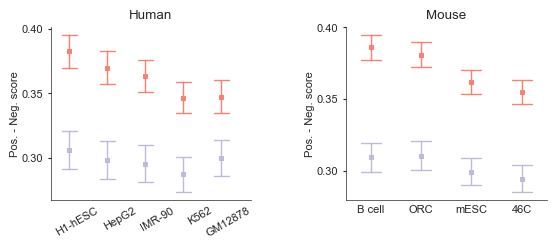

In [79]:
from matplotlib.ticker import MaxNLocator

cell_human = ['H1-hESC', 'HepG2', 'IMR-90', 'K562', 'GM12878']
cell_mouse = ['B cell', 'ORC', 'mESC', '46C']

def plot_std(data, orders, ax, title='', rotate=0):
    ax.clear()
    ax.set_aspect('auto')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    
    sns.pointplot(
        data=data, 
        x='CellType', 
        y='Value', 
        hue='Method', 
        palette=colors, 
        dodge=0, 
        capsize=0.4, 
        order=orders, 
        markers='s', 
        linestyle='none', 
        linewidth=1, 
        ax=ax, 
        legend=False,
        errorbar=('se', 10)
    )

    sns.despine(ax=ax)

    if rotate:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
        ax.set_xticks([p+0.8 for p in ax.get_xticks()])

    ax.set_xlabel('')
    ax.set_ylabel('Pos. - Neg. score')
    # ax.set_yscale('log')
    ax.tick_params(axis='y', length=2)
    ax.minorticks_off()
    # ax.set_ylim(1, 1000)
    ax.xaxis.labelpad = 1
    ax.yaxis.labelpad = 1
    ax.set_title(title)

    # ax.legend(
    #     title=None,
    #     frameon=False,
    #     loc='best',          # 图例左边在左侧中点附近
    #     fontsize=7,
    # )
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))


plot_std(gap_human, cell_human, axes[0][0], 'Human', rotate=30)
plot_std(gap_mouse, cell_mouse, axes[0][1], 'Mouse')
fig


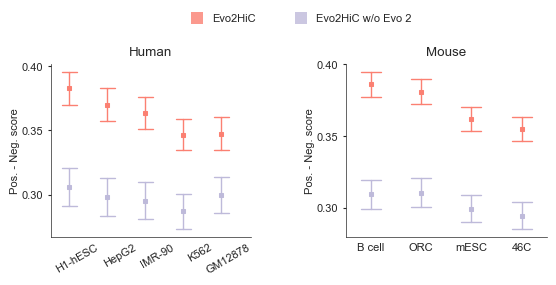

In [80]:
pos0, pos1 = axes[0][0].get_position(), axes[0][1].get_position()
x = (pos0.x0+pos1.x1)/2
y = pos0.y1 + 0.15

labels = ['Evo2HiC', 'Evo2HiC w/o Evo 2']

# 删除旧 legend（防止重复）
if hasattr(fig, "legend_") and fig.legend_ is not None:
    fig.legend_.remove()

handles = [Line2D([0],[0], marker='s', linestyle='', markersize=8,
                markerfacecolor=colors[i], markeredgewidth=0, alpha=0.8,
                label=m) for i, m in enumerate(labels)]

# 在左上角单独放 legend
fig.legend(
    handles, labels,
    loc='center',
    bbox_to_anchor=(x, y),  # 锚点设在左上角稍上方
    ncol=len(labels),
    frameon=False,
    fontsize=8,           # 字体更小
    handletextpad=0.4,    # 图例符号与文字间距
    columnspacing=3,    # 各列间距
    borderaxespad=0.1     # 与轴的边界间距
)
fig

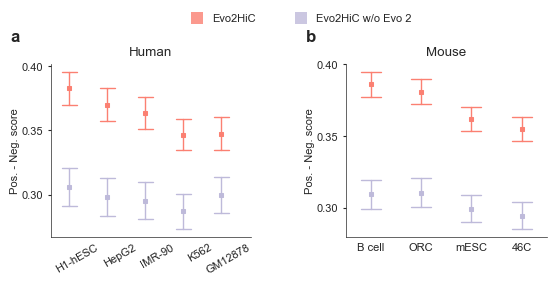

In [81]:
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i','j']
axs = [axes[0][0], axes[0][1]]

for ax, label in zip(axs, labels):
    ax.text(
        -0.2, 1.2, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )
fig

In [ ]:
fig.savefig(str(OUT_DIR / 'supplementary_1.pdf'))